# GridSense
## Forecasting Electricity Outage Risk in Addis Ababa Using Community Reports, Time, Location, and Weather

This project focuses on a local Addis Ababa issue: electricity outages that disrupt studying, business operations, remote work, and daily planning.

Because public outage datasets are limited, I use community-reported data and convert it into a forecasting-ready dataset. I then train a two-stage modeling system:

1. **Model 1 (Forecasting):** outage risk probability (`outage_occurred`).
2. **Model 2 (Conditional impact):** likely severity/duration if an outage occurs.

The goal is practical local value: improve planning and awareness, not replace official utility communication.


## Main research question
Can community-reported data, time features, location, planning status, and weather conditions be used to estimate electricity outage risk in Addis Ababa?

## Sub-questions
1. When are outages most likely to be reported?
2. Where are outage risks highest?
3. Are rainy/stormy conditions associated with higher outage risk or longer duration?
4. Can a model estimate outage probability for a given time and location?
5. If an outage happens, can we estimate likely duration or severity?


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, r2_score

ROOT = Path('..').resolve() if (Path.cwd().name == 'notebooks') else Path('.').resolve()
print('ROOT=', ROOT)


ROOT= C:\Users\lisan\Desktop\mebratwatch-addis-nosynthetic


## Data pipeline and sources

- Raw community intake: `data/collected/community_outage_reports.csv`
- Clean event-level dataset: `data/processed/community_outage_reports_clean.csv`
- Forecasting window dataset (built): `data/processed/gridsense_forecasting_dataset.csv`

The forecasting dataset is constructed as one row per **date + sub-city + 3-hour time window**, with both outage (`1`) and no-outage (`0`) windows.


In [2]:
import runpy
runpy.run_path(str(ROOT / 'src' / 'build_forecasting_dataset.py'), run_name='__main__')

forecast_df = pd.read_csv(ROOT / 'data/processed/gridsense_forecasting_dataset.csv')
forecast_df.head()


{
  "rows": 1584,
  "outage_occurred_counts": {
    "0": 1489,
    "1": 95
  },
  "high_severity_outage_counts": {
    "0": 1519,
    "1": 65
  },
  "sub_city_count": 11,
  "date_count": 18,
  "time_windows": [
    "00:00-03:00",
    "03:00-06:00",
    "06:00-09:00",
    "09:00-12:00",
    "12:00-15:00",
    "15:00-18:00",
    "18:00-21:00",
    "21:00-00:00"
  ]
}


,date,sub_city,hour_block_start,time_window,day_of_week,reports_count,outage_occurred,avg_duration_hours,max_duration_hours,high_severity_outage,weather_condition,is_rainy,planned_notice_mode,representative_sefer,confidence_score_mean,respondents_count_proxy
0,2026-04-12,addis ketema,0,00:00-03:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
1,2026-04-12,addis ketema,3,03:00-06:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
2,2026-04-12,addis ketema,6,06:00-09:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
3,2026-04-12,addis ketema,9,09:00-12:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
4,2026-04-12,addis ketema,12,12:00-15:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0


In [3]:
print('forecast_df shape:', forecast_df.shape)
print('outage_occurred balance:')
print(forecast_df['outage_occurred'].value_counts())
print('high_severity_outage balance:')
print(forecast_df['high_severity_outage'].value_counts())
print('sub_city count:', forecast_df['sub_city'].nunique())
print('date count:', forecast_df['date'].nunique())


forecast_df shape: (1584, 16)
outage_occurred balance:
outage_occurred
0    1489
1      95
Name: count, dtype: int64
high_severity_outage balance:
high_severity_outage
0    1519
1      65
Name: count, dtype: int64
sub_city count: 11
date count: 18


## Exploratory analysis: outage risk patterns


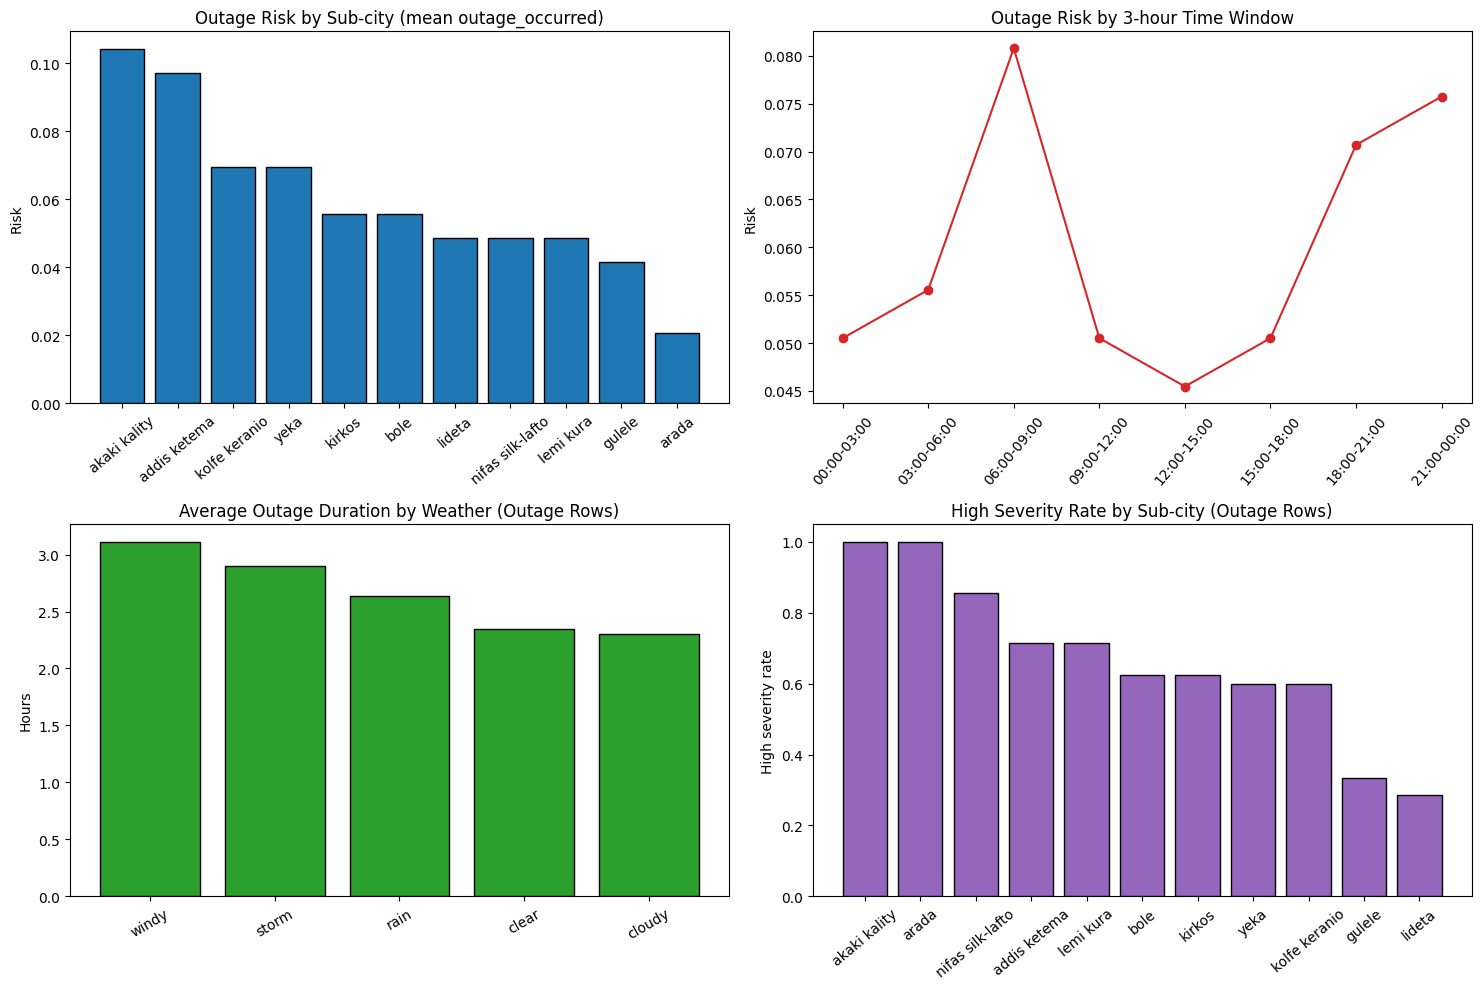

In [4]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

# Outage rate by sub-city
city_risk = forecast_df.groupby('sub_city')['outage_occurred'].mean().sort_values(ascending=False)
axes[0,0].bar(city_risk.index, city_risk.values, color='#1f77b4', edgecolor='black')
axes[0,0].set_title('Outage Risk by Sub-city (mean outage_occurred)')
axes[0,0].set_ylabel('Risk')
axes[0,0].tick_params(axis='x', rotation=40)

# Outage risk by 3-hour window
tw_risk = forecast_df.groupby('time_window')['outage_occurred'].mean().sort_index()
axes[0,1].plot(tw_risk.index, tw_risk.values, marker='o', color='#d62728')
axes[0,1].set_title('Outage Risk by 3-hour Time Window')
axes[0,1].set_ylabel('Risk')
axes[0,1].tick_params(axis='x', rotation=50)

# Avg duration by weather (outage rows)
out_df = forecast_df[forecast_df['outage_occurred']==1]
w_dur = out_df.groupby('weather_condition')['avg_duration_hours'].mean().sort_values(ascending=False)
axes[1,0].bar(w_dur.index, w_dur.values, color='#2ca02c', edgecolor='black')
axes[1,0].set_title('Average Outage Duration by Weather (Outage Rows)')
axes[1,0].set_ylabel('Hours')
axes[1,0].tick_params(axis='x', rotation=30)

# Severity by sub-city
sev = out_df.groupby('sub_city')['high_severity_outage'].mean().sort_values(ascending=False)
axes[1,1].bar(sev.index, sev.values, color='#9467bd', edgecolor='black')
axes[1,1].set_title('High Severity Rate by Sub-city (Outage Rows)')
axes[1,1].set_ylabel('High severity rate')
axes[1,1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()


## Statistics: rainy vs non-rainy outage duration


In [5]:
rainy = out_df[out_df['is_rainy']==1]['avg_duration_hours'].dropna()
non_rainy = out_df[out_df['is_rainy']==0]['avg_duration_hours'].dropna()

t_stat, p_value = ttest_ind(rainy, non_rainy, alternative='greater', equal_var=False)


def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

print('rainy mean:', round(rainy.mean(),2), 'hours')
print('non-rainy mean:', round(non_rainy.mean(),2), 'hours')
print('t-stat:', round(float(t_stat),4), 'p-value:', round(float(p_value),6))
if len(rainy)>=2 and len(non_rainy)>=2:
    print("Cohen's d:", round(float(cohens_d(rainy, non_rainy)),3))


rainy mean: 2.61 hours
non-rainy mean: 2.53 hours
t-stat: 0.5379 p-value: 0.295984
Cohen's d: 0.107


## Regression: explaining outage duration


In [6]:
reg_df = out_df.copy()
reg = smf.ols('avg_duration_hours ~ hour_block_start + is_rainy + C(sub_city) + C(planned_notice_mode)', data=reg_df).fit()
print(reg.summary())


                            OLS Regression Results                            
Dep. Variable:     avg_duration_hours   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     1.548
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.113
Time:                        17:07:27   Log-Likelihood:                -97.101
No. Observations:                  95   AIC:                             224.2
Df Residuals:                      80   BIC:                             262.5
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

## Two-stage modeling system

### Model 1: Outage risk forecasting
Target: `outage_occurred`

### Model 2: Conditional impact modeling
Scope: only rows with `outage_occurred=1`
- Severity classifier target: `high_severity_outage`
- Duration regressor target: `avg_duration_hours`


In [7]:
import runpy
runpy.run_path(str(ROOT / 'src' / 'train_two_stage_models.py'), run_name='__main__')

metrics = json.loads((ROOT / 'reports/tables/two_stage_model_metrics.json').read_text(encoding='utf-8'))
metrics


{
  "dataset_rows": 1584,
  "stage1_outage_forecasting": {
    "target": "outage_occurred",
    "features": [
      "hour_block_start",
      "day_of_week",
      "sub_city",
      "weather_condition",
      "is_rainy",
      "planned_notice_mode"
    ],
    "class_balance": {
      "0": 1489,
      "1": 95
    },
    "models": [
      {
        "model": "dummy_baseline",
        "accuracy": 0.9394,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "roc_auc": 0.5,
        "confusion_matrix": {
          "tn": 372,
          "fp": 0,
          "fn": 24,
          "tp": 0
        }
      },
      {
        "model": "logistic_regression",
        "accuracy": 0.9747,
        "precision": 0.7917,
        "recall": 0.7917,
        "f1": 0.7917,
        "roc_auc": 0.9929,
        "confusion_matrix": {
          "tn": 367,
          "fp": 5,
          "fn": 5,
          "tp": 19
        }
      },
      {
        "model": "random_forest",
        "accuracy": 0.9621,
 

{'dataset_rows': 1584,
 'stage1_outage_forecasting': {'target': 'outage_occurred',
  'features': ['hour_block_start',
   'day_of_week',
   'sub_city',
   'weather_condition',
   'is_rainy',
   'planned_notice_mode'],
  'class_balance': {'0': 1489, '1': 95},
  'models': [{'model': 'dummy_baseline',
    'accuracy': 0.9394,
    'precision': 0.0,
    'recall': 0.0,
    'f1': 0.0,
    'roc_auc': 0.5,
    'confusion_matrix': {'tn': 372, 'fp': 0, 'fn': 24, 'tp': 0}},
   {'model': 'logistic_regression',
    'accuracy': 0.9747,
    'precision': 0.7917,
    'recall': 0.7917,
    'f1': 0.7917,
    'roc_auc': 0.9929,
    'confusion_matrix': {'tn': 367, 'fp': 5, 'fn': 5, 'tp': 19}},
   {'model': 'random_forest',
    'accuracy': 0.9621,
    'precision': 0.6154,
    'recall': 1.0,
    'f1': 0.7619,
    'roc_auc': 0.9888,
    'confusion_matrix': {'tn': 357, 'fp': 15, 'fn': 0, 'tp': 24}}]},
 'stage2_conditional_models': {'scope': 'rows where outage_occurred == 1',
  'rows': 95,
  'features': ['hour_blo

In [8]:
# Model 1 (forecasting) metric table
m1 = pd.DataFrame(metrics['stage1_outage_forecasting']['models'])
m1


,model,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,dummy_baseline,0.9394,0.0000,0.0000,0.0000,0.5000,"{'tn': 372, 'fp': 0, 'fn': 24, 'tp': 0}"
1,logistic_regression,0.9747,0.7917,0.7917,0.7917,0.9929,"{'tn': 367, 'fp': 5, 'fn': 5, 'tp': 19}"
2,random_forest,0.9621,0.6154,1.0000,0.7619,0.9888,"{'tn': 357, 'fp': 15, 'fn': 0, 'tp': 24}"


In [9]:
# Quick probability example using Model 1 (logistic)
stage1_features = [
    'hour_block_start','day_of_week','sub_city','weather_condition','is_rainy','planned_notice_mode'
]
X = forecast_df[stage1_features]
y = forecast_df['outage_occurred'].astype(int)

num = ['hour_block_start','is_rainy']
cat = ['day_of_week','sub_city','weather_condition','planned_notice_mode']
prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),('oh', OneHotEncoder(handle_unknown='ignore'))]), cat)
])

pipe = Pipeline([('prep', prep), ('model', LogisticRegression(max_iter=2000, random_state=42))])
pipe.fit(X,y)

example = pd.DataFrame([{
    'hour_block_start': 20,
    'day_of_week': 'Friday',
    'sub_city': 'bole',
    'weather_condition': 'rain',
    'is_rainy': 1,
    'planned_notice_mode': 'unknown'
}])

prob = pipe.predict_proba(example)[0,1]
print(f"Example forecast -> Bole, Friday, 20:00, rainy: outage risk = {prob:.1%}")


Example forecast -> Bole, Friday, 20:00, rainy: outage risk = 54.7%


## Practical interpretation

- If Model 1 predicts high outage risk for a location/time/weather combination, people and businesses can prepare.
- If an outage occurs, Model 2 gives likely severity/duration expectations.
- This is a planning and awareness prototype, not an official outage alert system.


## Limitations

1. Community reports are not a full utility monitoring system.
2. Some no-outage windows are inferred from no-report windows in the aggregation process.
3. Geographic coverage and participation can vary by sub-city and date.
4. Weather and planning labels are community-reported, so they include uncertainty.


## Final conclusion

GridSense now aligns directly with a forecasting mission:

- It transforms local community reports into a time-location outage-risk dataset.
- It uses a two-stage model design: outage risk first, then conditional impact.
- It provides locally useful planning insight while remaining transparent about limits.

This is a practical path toward local outage-risk awareness in Addis Ababa, and it can be improved with more reports, better coverage, and official outage notice integration.
